### Setup

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[1]          # the notebook sits in analytics/notebooks/
RAW = ROOT / "data" / "raw"
pd.set_option("display.max_columns", 30)
print(RAW.exists())

True


### One season first

In [2]:
df = pd.read_csv(RAW / "football_data" / "E0_2425.csv", encoding="latin-1")
print(df.shape)
df.head()

(380, 120)


,ï»¿Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,...,AvgC>2.5,AvgC<2.5,BFEC>2.5,BFEC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,16/08/2024,20:00,Man United,Fulham,1,0,H,0,0,D,R Jones,14,10,5,...,1.61,2.37,1.68,2.46,-0.75,1.86,2.07,1.83,2.11,1.88,2.11,1.82,2.05,1.90,2.08
1,E0,17/08/2024,12:30,Ipswich,Liverpool,0,2,A,0,0,D,T Robinson,7,18,2,...,1.37,3.18,1.40,3.40,1.50,2.05,1.88,2.04,1.90,2.20,2.00,1.99,1.88,2.04,1.93
2,E0,17/08/2024,15:00,Arsenal,Wolves,2,0,H,1,0,H,J Gillett,18,9,6,...,1.42,2.93,1.44,3.20,-2.25,2.02,1.91,2.00,1.90,2.05,1.93,1.99,1.87,2.02,1.96
3,E0,17/08/2024,15:00,Everton,Brighton,0,3,A,0,1,A,S Hooper,9,10,1,...,1.89,1.96,1.94,2.04,0.25,1.87,2.06,1.86,2.07,1.92,2.10,1.83,2.04,1.88,2.11
4,E0,17/08/2024,15:00,Newcastle,Southampton,1,0,H,1,0,H,C Pawson,3,19,1,...,1.43,2.84,1.49,2.98,-1.25,1.87,2.06,1.88,2.06,1.89,2.10,1.82,2.05,1.89,2.10


### Columns and types

In [3]:
cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "HS", "AS", "HST", "AST"]
df[cols].dtypes


Date          str
HomeTeam      str
AwayTeam      str
FTHG        int64
FTAG        int64
FTR           str
HS          int64
AS          int64
HST         int64
AST         int64
dtype: object

### Teams

In [4]:
teams = sorted(df["HomeTeam"].unique())
print(len(teams))
print(teams)

20
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich', 'Leicester', 'Liverpool', 'Man City', 'Man United', 'Newcastle', "Nott'm Forest", 'Southampton', 'Tottenham', 'West Ham', 'Wolves']


###  How often does each result happen?

In [5]:
df["FTR"].value_counts(normalize=True).round(3)

FTR
H    0.408
A    0.347
D    0.245
Name: proportion, dtype: float64

### Goals per match

count    380.00
mean       2.93
std        1.62
min        0.00
25%        2.00
50%        3.00
75%        4.00
max        9.00
Name: total_goals, dtype: float64


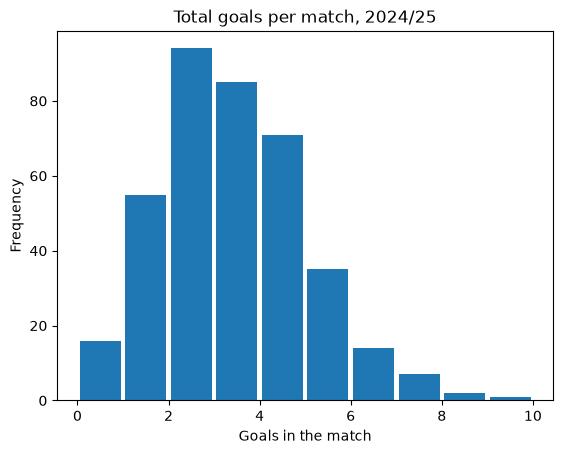

In [8]:
df["total_goals"] = df["FTHG"] + df["FTAG"]
print(df["total_goals"].describe().round(2))
df["total_goals"].plot(kind="hist", bins=range(0, 11), rwidth=0.9,
                       title="Total goals per match, 2024/25")
plt.xlabel("Goals in the match")
plt.show()

### Shots and goals

Shots per goal: 8.8
On target % of shots: 35.1
Correlation, home shots on target vs home goals: 0.57


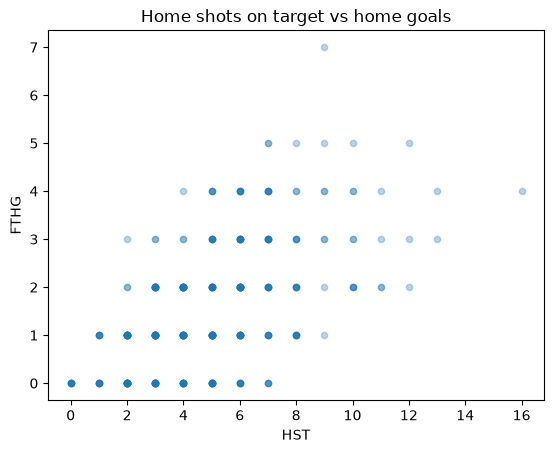

In [9]:
shots = df[["HS", "AS"]].sum().sum()
on_target = df[["HST", "AST"]].sum().sum()
goals = df[["FTHG", "FTAG"]].sum().sum()
print("Shots per goal:", round(shots / goals, 1))
print("On target % of shots:", round(on_target / shots * 100, 1))
print("Correlation, home shots on target vs home goals:",
      round(df["HST"].corr(df["FTHG"]), 2))
df.plot(kind="scatter", x="HST", y="FTHG", alpha=0.3,
        title="Home shots on target vs home goals")
plt.show()

###  All seasons: blank rows and missing stats

In [10]:
frames = []
for f in sorted((RAW / "football_data").glob("E0_*.csv")):
    d = pd.read_csv(f, encoding="latin-1", on_bad_lines="skip")
    d["file"] = f.stem
    frames.append(d)
allm = pd.concat(frames, ignore_index=True)
print("Rows:", len(allm))
print("Blank rows:", allm["HomeTeam"].isna().sum())
allm = allm.dropna(subset=["HomeTeam"])
coverage = (allm.groupby("file")[["FTHG", "HS", "HST", "HC", "HY", "Referee"]]
                .apply(lambda g: g.notna().mean()).round(2))
coverage

C:\Users\admin\AppData\Local\Temp\ipykernel_116\2737076591.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["file"] = f.stem


Rows: 13361
Blank rows: 697


,FTHG,HS,HST,HC,HY,Referee
file,,,,,,
E0_0001,1.0,1.0,1.0,1.0,1.0,1.0
E0_0102,1.0,1.0,1.0,1.0,1.0,1.0
E0_0203,1.0,1.0,1.0,1.0,1.0,1.0
E0_0304,1.0,1.0,1.0,1.0,1.0,1.0
E0_0405,1.0,1.0,1.0,1.0,1.0,1.0
E0_0506,1.0,1.0,1.0,1.0,1.0,1.0
E0_0607,1.0,1.0,1.0,1.0,1.0,1.0
E0_0708,1.0,1.0,1.0,1.0,1.0,1.0
E0_0809,1.0,1.0,1.0,1.0,1.0,1.0


### Date formats

In [11]:
allm.groupby("file")["Date"].first()

file
E0_0001      19/08/00
E0_0102      18/08/01
E0_0203    17/08/2002
E0_0304      16/08/03
E0_0405      14/08/04
E0_0506      13/08/05
E0_0607      19/08/06
E0_0708      11/08/07
E0_0809      16/08/08
E0_0910      15/08/09
E0_1011      14/08/10
E0_1112      13/08/11
E0_1213      18/08/12
E0_1314      17/08/13
E0_1415      16/08/14
E0_1516    08/08/2015
E0_1617      13/08/16
E0_1718    11/08/2017
E0_1819    10/08/2018
E0_1920    09/08/2019
E0_2021    12/09/2020
E0_2122    13/08/2021
E0_2223    05/08/2022
E0_2324    11/08/2023
E0_2425    16/08/2024
E0_2526    15/08/2025
E0_2627    21/08/2026
E0_9394      14/08/93
E0_9495      20/08/94
E0_9596      19/08/95
E0_9697      17/08/96
E0_9798      09/08/97
E0_9899      15/08/98
E0_9900      07/08/99
Name: Date, dtype: str

### Trends across seasons

C:\Users\admin\AppData\Local\Temp\ipykernel_116\3574870279.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  allm["total_goals"] = allm["FTHG"] + allm["FTAG"]


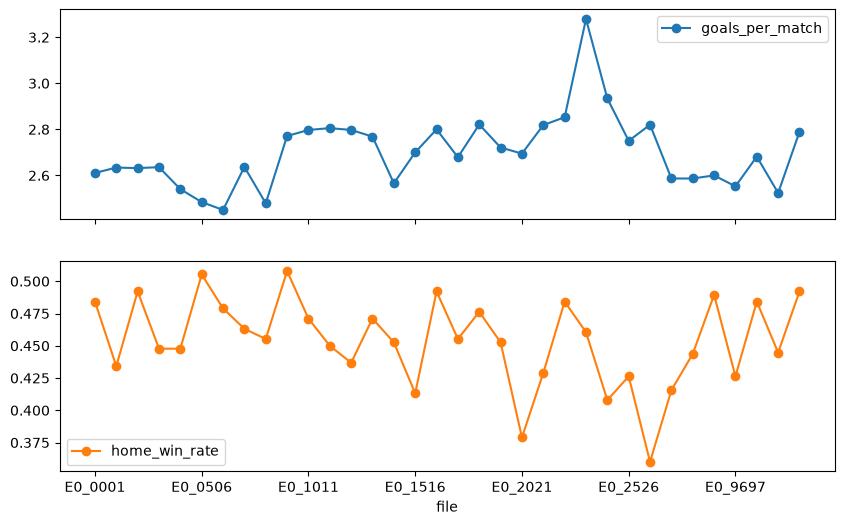

In [12]:

allm["total_goals"] = allm["FTHG"] + allm["FTAG"]
by_season = allm.groupby("file").agg(
    goals_per_match=("total_goals", "mean"),
    home_win_rate=("FTR", lambda s: (s == "H").mean()),
)
by_season.plot(subplots=True, marker="o", figsize=(10, 6))
plt.show()

### Understat: names and xG

In [13]:
u = pd.read_csv(RAW / "understat" / "schedule.csv")
u = u[u["is_result"].eq(True)]
print("Understat names not in football-data:")
print(sorted(set(u["home_team"]) - set(allm["HomeTeam"])))

s = u[u["season"] == 2425]
home = s.groupby("home_team")[["home_goals", "home_xg"]].sum()
away = s.groupby("away_team")[["away_goals", "away_xg"]].sum()
team = pd.DataFrame({"goals": home["home_goals"] + away["away_goals"],
                     "xg": home["home_xg"] + away["away_xg"]})
team["goals_minus_xg"] = team["goals"] - team["xg"]
team.sort_values("goals_minus_xg").round(1)

Understat names not in football-data:
['Manchester City', 'Manchester United', 'Newcastle United', 'Nottingham Forest', 'Queens Park Rangers', 'West Bromwich Albion', 'Wolverhampton Wanderers']


,goals,xg,goals_minus_xg
home_team,,,
Crystal Palace,51.0,67.8,-16.8
Bournemouth,58.0,72.6,-14.6
Manchester United,44.0,56.9,-12.9
Southampton,26.0,38.6,-12.6
Chelsea,64.0,73.1,-9.1
Aston Villa,58.0,66.4,-8.4
Liverpool,86.0,93.2,-7.2
Leicester,33.0,38.1,-5.1
Everton,42.0,46.9,-4.9
